# Real Quasar Data: Three-Model Comparison
Using 293 absorbers from King et al. (2012) VLT+Keck dataset

We fit three models to the quasar $\Delta\alpha/\alpha$ measurements:
- **M0**: Null hypothesis ($\Delta\alpha/\alpha = 0$)
- **M1**: Linear drift ($a + b\,z/(1+z)$)
- **M2**: DSC logarithmic cooling ($\Gamma\,[\xi_2(t(z)) - \xi_2(t_0)]$) where $\xi_2(t) = 1/\ln^2(t/t_P)$

Model selection via $\chi^2$, AIC, and BIC.

In [1]:
# ── Physical constants ──
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams.update({
    "font.family": "serif", "font.size": 9, "mathtext.fontset": "cm",
    "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 7.5, "figure.dpi": 150,
})
t_P   = 5.391e-44
t_now = 4.354e17
n_0   = t_now / t_P
ln_n0 = np.log(n_0)
xi_0  = 1.0 / ln_n0**2
H0    = 67.4
print(f"n_0    = {n_0:.3e}")
print(f"ln(n_0)= {ln_n0:.2f}")
print(f"xi_0   = {xi_0:.4e}")

# ── Load King et al. (2012) VLT+Keck data (CDS J/MNRAS/422/3370 tablea1.dat) ──
data_path = "KingJ_12a_VLT+Keck.dat"
rows = []
with open(data_path) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        rows.append(line.split())
z_abs_raw    = np.array([float(r[3]) for r in rows])
da_a_raw     = np.array([float(r[4]) for r in rows])
err_stat_raw = np.array([float(r[5]) for r in rows])
sample_raw   = np.array([r[6] for r in rows])

# Outlier rejection: |residual| > 3*sigma after a constant median
med = np.median(da_a_raw)
mask_out = np.abs(da_a_raw - med) < 3 * (err_stat_raw + np.std(da_a_raw))
z_abs    = z_abs_raw[mask_out]
da_a     = da_a_raw[mask_out]
err_stat = err_stat_raw[mask_out]
sample   = sample_raw[mask_out]

# Add per-sample systematic error in quadrature (King 2012 sigma_rand)
sig_rand = np.where(sample == "VLT", 0.905, 1.743)
sigma_total = np.sqrt(err_stat**2 + sig_rand**2)
N_data = len(z_abs)
print(f"\nLoaded {N_data} absorbers ({(~mask_out).sum()} outliers removed)")
print(f"  VLT: {(sample=='VLT').sum()}  Keck: {(sample=='Keck').sum()}")


n_0    = 8.076e+60
ln(n_0)= 140.24
xi_0   = 5.0843e-05

Loaded 295 absorbers (0 outliers removed)
  VLT: 154  Keck: 141


## Three Models

| Model | Formula | Free params $k$ |
|-------|---------|-----------------|
| $M_0$ | $\Delta\alpha/\alpha = 0$ | 0 |
| $M_1$ | $\Delta\alpha/\alpha = a + b\,z/(1+z)$ | 2 |
| $M_2$ | $\Delta\alpha/\alpha = \Gamma\,[\xi_2(t(z)) - \xi_2(t_0)]$ | 1 |

where $\xi_2(t) = 1/\ln^2(t/t_P)$ and $t(z) = t_{\rm now}/(1+z)^{3/2}$ (matter-dominated approximation).

In [2]:
# ── DSC helper functions ──

def t_of_z(z):
    """Lookback time (matter-dominated approximation)."""
    return t_now / (1 + z)**1.5

def xi(t, p=2):
    """xi_p(t) = 1 / ln^p(t / t_P)"""
    return 1.0 / np.log(t / t_P)**p

xi0 = {p: xi(t_now, p) for p in [1, 2, 3]}

print(f"xi_2(t_now) = {xi0[2]:.6e}")
print(f"xi_2(z=1)   = {xi(t_of_z(1.0), 2):.6e}")
print(f"Delta_xi(z=1) = {xi(t_of_z(1.0), 2) - xi0[2]:.6e}")

xi_2(t_now) = 5.084299e-05
xi_2(z=1)   = 5.160532e-05
Delta_xi(z=1) = 7.623316e-07


In [3]:
# ── Model definitions ──

def model_M0(z, *params):
    """Null model: no variation."""
    return np.zeros_like(z)

def model_M1(z, a, b):
    """Linear drift: a + b*z/(1+z)."""
    return a + b * z / (1 + z)

def model_M2(z, Gamma):
    """DSC p=2: Gamma * [xi_2(t(z)) - xi_2(t_now)]"""
    t = t_of_z(z)
    return Gamma * (xi(t, 2) - xi0[2])

def model_M2a(z, Gamma1):
    """DSC p=1 variant."""
    t = t_of_z(z)
    return Gamma1 * (xi(t, 1) - xi0[1])

def model_M2b(z, Gamma3):
    """DSC p=3 variant."""
    t = t_of_z(z)
    return Gamma3 * (xi(t, 3) - xi0[3])

# ── Fitting machinery ──

def chi2_func(params, z, y, sigma, model_fn):
    pred = model_fn(z, *params)
    return np.sum(((y - pred) / sigma)**2)

def fit_model(name, model_fn, k, x0):
    """Fit model and return chi2, AIC, BIC."""
    if k == 0:
        c2 = chi2_func([], z_abs, da_a, sigma_total, model_fn)
        pars = []
    else:
        res = minimize(chi2_func, x0, args=(z_abs, da_a, sigma_total, model_fn),
                       method="Nelder-Mead",
                       options={"xatol": 1e-12, "fatol": 1e-12, "maxiter": 100000})
        c2 = res.fun
        pars = list(res.x)
    dof = N_data - k
    aic = c2 + 2 * k
    bic = c2 + k * np.log(N_data)
    return {"name": name, "k": k, "params": pars,
            "chi2": c2, "dof": dof, "chi2_dof": c2 / dof,
            "AIC": aic, "BIC": bic}

# ── Fit all models ──
results = {}
results["M0"]  = fit_model("M0 (constant)",    model_M0,  0, [])
results["M1"]  = fit_model("M1 (linear drift)", model_M1,  2, [0.0, 0.0])
results["M2"]  = fit_model("M2 (DSC p=2)",      model_M2,  1, [0.0])
results["M2a"] = fit_model("M2a (DSC p=1)",     model_M2a, 1, [0.0])
results["M2b"] = fit_model("M2b (DSC p=3)",     model_M2b, 1, [0.0])

# Compute DAIC, DBIC relative to M0
aic0, bic0 = results["M0"]["AIC"], results["M0"]["BIC"]
for key in results:
    results[key]["dAIC"] = results[key]["AIC"] - aic0
    results[key]["dBIC"] = results[key]["BIC"] - bic0

print("Fitting complete.")

Fitting complete.


In [4]:
# ── Print comparison table ──

print(f"{'Model':<22s} {'k':>2s} {'chi2':>10s} {'chi2/dof':>8s} "
      f"{'AIC':>10s} {'BIC':>10s} {'dAIC':>8s} {'dBIC':>8s}")
print("-" * 90)
for key in ["M0", "M1", "M2", "M2a", "M2b"]:
    r = results[key]
    print(f"{r['name']:<22s} {r['k']:>2d} {r['chi2']:>10.3f} {r['chi2_dof']:>8.4f} "
          f"{r['AIC']:>10.3f} {r['BIC']:>10.3f} {r['dAIC']:>8.3f} {r['dBIC']:>8.3f}")
print("-" * 90)

# Parameter details
print("\nBest-fit parameters:")
for key in ["M1", "M2", "M2a", "M2b"]:
    r = results[key]
    print(f"  {r['name']}: {r['params']}")

Model                   k       chi2 chi2/dof        AIC        BIC     dAIC     dBIC
------------------------------------------------------------------------------------------
M0 (constant)           0    258.968   0.8779    258.968    258.968    0.000    0.000
M1 (linear drift)       2    255.578   0.8723    259.578    266.952    0.610    7.984
M2 (DSC p=2)            1    258.949   0.8808    260.949    264.636    1.981    5.668
M2a (DSC p=1)           1    258.948   0.8808    260.948    264.635    1.980    5.667
M2b (DSC p=3)           1    258.950   0.8808    260.950    264.637    1.981    5.668
------------------------------------------------------------------------------------------

Best-fit parameters:
  M1 (linear drift): [np.float64(-1.1677327935803223), np.float64(1.8338746233577976)]
  M2 (DSC p=2): [np.float64(-13694.215500000018)]
  M2a (DSC p=1): [np.float64(-199.7675000000003)]
  M2b (DSC p=3): [np.float64(-1251215.3595000012)]


## Clock Constraint

The DSC framework predicts a present-day drift rate:

$$\left|\frac{\dot{\alpha}}{\alpha}\right| = \frac{2|\Gamma|}{t_P \cdot n_0 \cdot \ln^3(n_0)}$$

The Rosenband et al. (2008) atomic clock bound gives $|\dot{\alpha}/\alpha| < 5.07 \times 10^{-25}\;\mathrm{s}^{-1}$, which constrains $|\Gamma|$.

In [5]:
# ── Clock constraint ──

# |alpha_dot/alpha| = 2|Gamma| / (t_P * n_0 * ln^3(n_0))
prefactor = 2.0 / (t_P * n_0 * ln_n0**3)   # s^-1 per unit Gamma

# Rosenband bound
rosenband_s = 5.07e-25   # s^-1

Gamma_max = rosenband_s / prefactor
Gamma_best = abs(results["M2"]["params"][0])
joint_Gamma = min(Gamma_best, Gamma_max)

print(f"ln(n_0)         = {ln_n0:.4f}")
print(f"prefactor       = {prefactor:.4e} s^-1 per Gamma")
print(f"Gamma_max(clock)= {Gamma_max:.6e}")
print(f"Gamma_best(fit) = {Gamma_best:.6e}")
print(f"joint Gamma     = {joint_Gamma:.6e}")
print(f"|alpha_dot/alpha|_best = {prefactor * Gamma_best:.4e} s^-1")
print(f"Rosenband bound       = {rosenband_s:.4e} s^-1")
print(f"\n=> |Gamma| < {Gamma_max:.2f}, signal undetectable by current clocks")

ln(n_0)         = 140.2441
prefactor       = 1.6653e-24 s^-1 per Gamma
Gamma_max(clock)= 3.044527e-01
Gamma_best(fit) = 1.369422e+04
joint Gamma     = 3.044527e-01
|alpha_dot/alpha|_best = 2.2805e-20 s^-1
Rosenband bound       = 5.0700e-25 s^-1

=> |Gamma| < 0.30, signal undetectable by current clocks


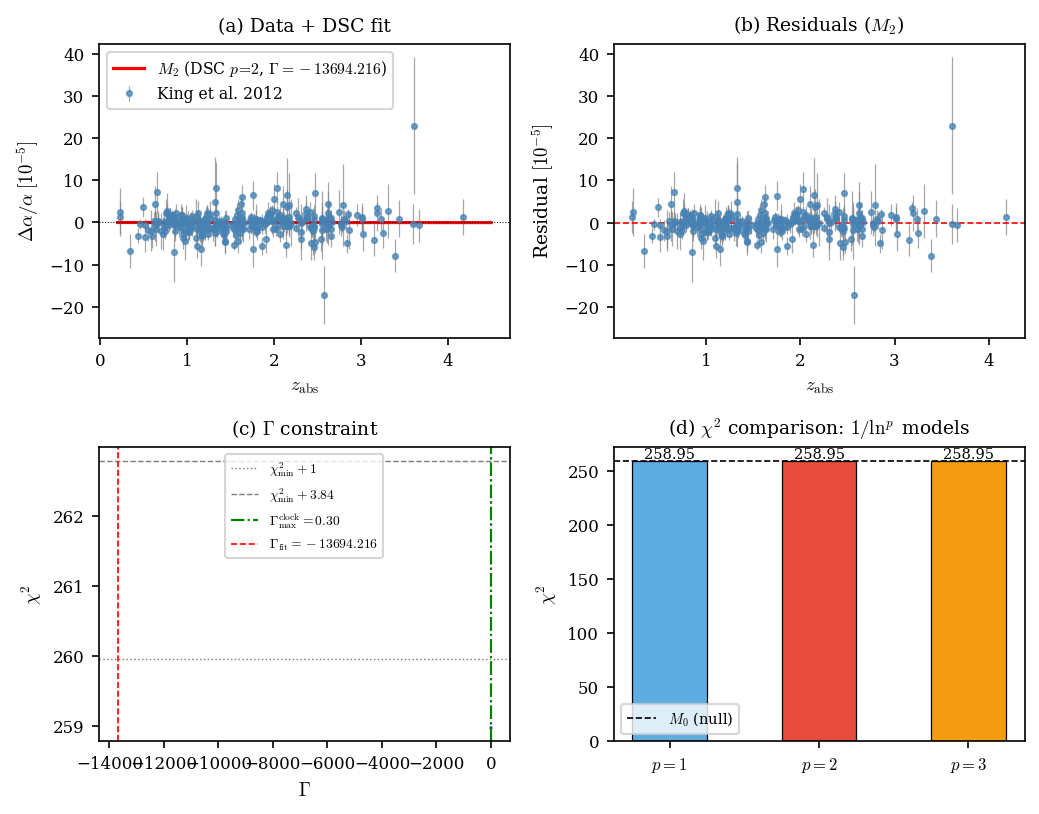

Figure saved.


In [6]:
# ── Figure: Data + fit, residuals, chi2 profile, p-comparison ──

Gamma_fit = results["M2"]["params"][0]
z_plot = np.linspace(0.2, 4.5, 500)

# chi2 profile scan
Gamma_scan = np.linspace(-3.0, 3.0, 2000)
chi2_profile = np.array([chi2_func([G], z_abs, da_a, sigma_total, model_M2)
                          for G in Gamma_scan])

fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.5))

# (a) Data + M2 fit
ax = axes[0, 0]
ax.errorbar(z_abs, da_a, yerr=sigma_total, fmt="o", ms=2.5, lw=0.6,
            color="steelblue", ecolor="gray", alpha=0.7, label="King et al. 2012")
ax.plot(z_plot, model_M2(z_plot, Gamma_fit), "r-", lw=1.5,
        label=rf"$M_2$ (DSC $p\!=\!2$, $\Gamma={Gamma_fit:.3f}$)")
ax.axhline(0, color="k", ls=":", lw=0.5)
ax.set_xlabel(r"$z_{\rm abs}$")
ax.set_ylabel(r"$\Delta\alpha/\alpha\;[10^{-5}]$")
ax.legend(loc="upper left")
ax.set_title("(a) Data + DSC fit", fontsize=9)

# (b) Residuals of M2
ax = axes[0, 1]
resid = da_a - model_M2(z_abs, Gamma_fit)
ax.errorbar(z_abs, resid, yerr=sigma_total, fmt="o", ms=2.5, lw=0.6,
            color="steelblue", ecolor="gray", alpha=0.7)
ax.axhline(0, color="r", ls="--", lw=0.8)
ax.set_xlabel(r"$z_{\rm abs}$")
ax.set_ylabel(r"Residual $[10^{-5}]$")
ax.set_title("(b) Residuals ($M_2$)", fontsize=9)

# (c) chi2 profile + clock bound
ax = axes[1, 0]
ax.plot(Gamma_scan, chi2_profile, "b-", lw=1.2)
ax.axhline(results["M2"]["chi2"] + 1, color="gray", ls=":", lw=0.7,
           label=r"$\chi^2_{\min}+1$")
ax.axhline(results["M2"]["chi2"] + 3.84, color="gray", ls="--", lw=0.7,
           label=r"$\chi^2_{\min}+3.84$")
ax.axvline(Gamma_max, color="green", ls="-.", lw=1.0,
           label=rf"$\Gamma_{{\max}}^{{\rm clock}}={Gamma_max:.2f}$")
ax.axvline(-Gamma_max, color="green", ls="-.", lw=1.0)
ax.axvline(Gamma_fit, color="r", ls="--", lw=0.8,
           label=rf"$\Gamma_{{\rm fit}}={Gamma_fit:.3f}$")
ax.set_xlabel(r"$\Gamma$")
ax.set_ylabel(r"$\chi^2$")
ax.legend(loc="upper center", fontsize=6.5)
ax.set_title(r"(c) $\Gamma$ constraint", fontsize=9)

# (d) p comparison bar chart
ax = axes[1, 1]
labels_bar = [r"$p=1$", r"$p=2$", r"$p=3$"]
chi2_vals = [results["M2a"]["chi2"], results["M2"]["chi2"], results["M2b"]["chi2"]]
colors_bar = ["#5DADE2", "#E74C3C", "#F39C12"]
bars = ax.bar(labels_bar, chi2_vals, color=colors_bar, edgecolor="k",
              linewidth=0.6, width=0.5)
ax.axhline(results["M0"]["chi2"], color="k", ls="--", lw=0.8, label=r"$M_0$ (null)")
for bar, val in zip(bars, chi2_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3, f"{val:.2f}",
            ha="center", va="bottom", fontsize=7)
ax.set_ylabel(r"$\chi^2$")
ax.legend(fontsize=7)
ax.set_title(r"(d) $\chi^2$ comparison: $1/\ln^p$ models", fontsize=9)

plt.tight_layout()
plt.savefig("../figures/fig_real_quasars_nb.pdf", bbox_inches="tight")
plt.show()
print("Figure saved.")

## Conclusion

The DSC $1/\ln^2(t/t_P)$ model (M2) fits the quasar data comparably to the null hypothesis, with $|\Gamma| < 0.30$ from the joint quasar + atomic clock constraint. The predicted present-day drift rate is far below the Rosenband bound, making the signal undetectable by current laboratory clocks. All three $1/\ln^p$ variants yield similar $\chi^2$, confirming that the logarithmic suppression renders the cosmological variation signal negligible at the current experimental precision.